# GESTIÓN Y ORGANIZACIÓN DE DATOS

## PRÁCTICA 2

## Lourdes

### EJERCICIOS

#### EJERCICIO 0

Cargad la base de datos.

In [33]:
#Instalar e importar librerías
import importlib
import subprocess
import sys
def install_and_import(package, alias=None):
    try: 
        importlib.import_module(package)
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", package])
    finally:
        module = importlib.import_module(package)
        if alias:
            globals()[alias] = module
        else:
            globals()[package] = module 
#Instalar e importar pandas y numpy 
import pandas as pd
import numpy as np

df = pd.read_excel("DATA_Coaches.xlsx")
df.replace([999, 987], np.nan, inplace=True)
df.head()


,t1scs1,t1scs2,t1scs3,t1scs4,t1scs5,t1scs6,t1scs7,t1scs8,t1scs9,t1scs10,...,t3cbq12,t3cbq13,t3cbq14,t3cbq15,t3ssq1,t3ssq2,t3ssq3,t3ssq4,t3ssq5,t3ssq6
0,3.0,4.0,4.0,5.0,3.0,3.0,3.0,4.0,4.0,2.0,...,2.0,2.0,2.0,1.0,4.0,4.0,5.0,4.0,4.0,5.0
1,5.0,4.0,4.0,4.0,5.0,2.0,4.0,5.0,5.0,4.0,...,2.0,1.0,1.0,1.0,3.0,5.0,4.0,3.0,5.0,5.0
2,5.0,5.0,5.0,5.0,4.0,5.0,5.0,5.0,4.0,2.0,...,1.0,1.0,1.0,1.0,5.0,5.0,5.0,5.0,5.0,5.0
3,3.0,3.0,4.0,4.0,3.0,3.0,3.0,4.0,3.0,4.0,...,1.0,3.0,2.0,2.0,4.0,4.0,5.0,4.0,5.0,4.0
4,3.0,3.0,5.0,5.0,3.0,4.0,2.0,4.0,3.0,4.0,...,2.0,2.0,2.0,2.0,5.0,5.0,5.0,5.0,5.0,5.0


#### EJERCICIO 1

Cread una función que permita invertir la puntuación de los ítems de las escalas incorporadas en la base de datos *DATA\_coaches*. A pesar que en esta base de datos todas las escalas tienen el mismo rango en la escala ordinal (de 1 a 5 puntos) haced que la función permita trabajar con cualquier escala ordinal a la que se le quiera invertir la puntuación. (1.5 puntos)

In [34]:
import pandas as pd
import numpy as np

#1. Invertir
def invertir_items(serie, min_val=1, max_val=5):
    return max_val + min_val - serie

#2. Listas
inversos_scs = [f"t{i}scs{j}" for i in range(1,4) for j in [1,4,8,9,11,12]]
inversos_cbq = [f"t{i}cbq{j}" for i in range(1,4) for j in [1,14]]

print("Invirtiendo...")
for col in inversos_scs + inversos_cbq:
    if col in df.columns:
        df[col + '_inv'] = invertir_items(df[col])
        print(f"✓ {col}")

print(df[['t1scs1','t1scs1_inv']].head())


Invirtiendo...
✓ t1scs1
✓ t1scs4
✓ t1scs8
✓ t1scs9
✓ t1scs11
✓ t1scs12
✓ t2scs1
✓ t2scs4
✓ t2scs8
✓ t2scs9
✓ t2scs11
✓ t2scs12
✓ t3scs1
✓ t3scs4
✓ t3scs8
✓ t3scs9
✓ t3scs11
✓ t3scs12
✓ t1cbq1
✓ t1cbq14
✓ t2cbq1
✓ t2cbq14
✓ t3cbq1
✓ t3cbq14
   t1scs1  t1scs1_inv
0     3.0         3.0
1     5.0         1.0
2     5.0         1.0
3     3.0         3.0
4     3.0         3.0


#### EJERCICIO 2

Utilizad la función anterior para invertir los ítems descritos en la Tabla 1 cuya codificación reza como <u>inversa</u>. Hecho esto, guardad estas nuevas variables sobre las originales. (1 punto)

In [35]:
import pandas as pd
import numpy as np


#1. Lista de columnas inversas
columnas_inversas = [
    # SCS inversas T1,T2,T3 
    "t1scs1", "t1scs4", "t1scs8", "t1scs9", "t1scs11", "t1scs12",
    "t2scs1", "t2scs4", "t2scs8", "t2scs9", "t2scs11", "t2scs12", 
    "t3scs1", "t3scs4", "t3scs8", "t3scs9", "t3scs11", "t3scs12",
    # CBQ inversas T1,T2,T3 
    "t1cbq1", "t1cbq14",
    "t2cbq1", "t2cbq14",
    "t3cbq1", "t3cbq14"
]

#2. Invertir ítems y sobreescribir columnas originales
for col in columnas_inversas:
    if col in df.columns:
        df[col] = invertir_items(df[col], min_val=1, max_val=5)
        print(f"✓ {col} invertida")
    else:
        print(f"✗ {col} no encontrada")

#3. Comprobación 
print(df[columnas_inversas[:4]].head())


✓ t1scs1 invertida
✓ t1scs4 invertida
✓ t1scs8 invertida
✓ t1scs9 invertida
✓ t1scs11 invertida
✓ t1scs12 invertida
✓ t2scs1 invertida
✓ t2scs4 invertida
✓ t2scs8 invertida
✓ t2scs9 invertida
✓ t2scs11 invertida
✓ t2scs12 invertida
✓ t3scs1 invertida
✓ t3scs4 invertida
✓ t3scs8 invertida
✓ t3scs9 invertida
✓ t3scs11 invertida
✓ t3scs12 invertida
✓ t1cbq1 invertida
✓ t1cbq14 invertida
✓ t2cbq1 invertida
✓ t2cbq14 invertida
✓ t3cbq1 invertida
✓ t3cbq14 invertida
   t1scs1  t1scs4  t1scs8  t1scs9
0     3.0     1.0     2.0     2.0
1     1.0     2.0     1.0     1.0
2     1.0     1.0     1.0     2.0
3     3.0     2.0     2.0     3.0
4     3.0     1.0     2.0     3.0


#### EJERCICIO 3

Calculad las puntuaciones totales de las escalas (autocompasión, burnout y apoyo social percibido). Guardad estas nuevas variables en la base de datos. (1 punto)

In [36]:
#1. Columnas completas por escala y tiempo
#1. SCS (Autocompasión) - 12 ítems x 3 tiempos
df['scs_total_t1'] = df[[f't1scs{i}' for i in range(1,13)]].fillna(0).sum(axis=1)
df['scs_total_t2'] = df[[f't2scs{i}' for i in range(1,13)]].fillna(0).sum(axis=1)
df['scs_total_t3'] = df[[f't3scs{i}' for i in range(1,13)]].fillna(0).sum(axis=1)

#2. CBQ (Burnout) - 15 ítems x 3 tiempos
df['cbq_total_t1'] = df[[f't1cbq{i}' for i in range(1,16)]].fillna(0).sum(axis=1)
df['cbq_total_t2'] = df[[f't2cbq{i}' for i in range(1,16)]].fillna(0).sum(axis=1)
df['cbq_total_t3'] = df[[f't3cbq{i}' for i in range(1,16)]].fillna(0).sum(axis=1)

#3. SSQ (Apoyo Social) - 6 ítems x 3 tiempos
df['ssq_total_t1'] = df[[f't1ssq{i}' for i in range(1,7)]].fillna(0).sum(axis=1)
df['ssq_total_t2'] = df[[f't2ssq{i}' for i in range(1,7)]].fillna(0).sum(axis=1)
df['ssq_total_t3'] = df[[f't3ssq{i}' for i in range(1,7)]].fillna(0).sum(axis=1)

print("9 puntuaciones totales creadas correctamente")
print(df[['scs_total_t1', 'cbq_total_t1', 'ssq_total_t1']].head())


#Calculamos las puntuaciones totales por escala y tiempo:
#Crucial: NA tratados como 0 para no perder información
#sum(..., skipna=False).fillna(0)

9 puntuaciones totales creadas correctamente
   scs_total_t1  cbq_total_t1  ssq_total_t1
0          32.0          27.0          24.0
1          31.0          28.0          25.0
2          34.0          26.0          30.0
3          38.0          26.0          24.0
4          36.0          25.0          30.0


#### EJERCICIO 4

Con las nuevas variables calculadas en el apartado anterior, haced una descripción estadística de las mismas en los tres momentos de estudio. Una posibilidad de tabla resumen se muestra en la plantilla del documento pdf. ($1$ punto)

In [37]:
#1. Usar las 9 variables del Ejercicio 3
totales = [
    'scs_total_t1', 'scs_total_t2', 'scs_total_t3',
    'cbq_total_t1', 'cbq_total_t2', 'cbq_total_t3',
    'ssq_total_t1', 'ssq_total_t2', 'ssq_total_t3'
]

#2. Verificar columnas disponibles
print("Columnas disponibles para análisis:")
print([col for col in totales if col in df.columns])

#3. Crear tabla descriptiva con describe()
resumen = df[totales].agg(['count', 'mean', 'std', 'min', 'max']).round(2).T
resumen.columns = ['N', 'Mean', 'SD', 'Min', 'Max']

#4. Mostrar resultado final
print("\nTABLA DESCRIPTIVA - ESCALAS POR MOMENTOS DE ESTUDIO")
print("=" * 70)
print(resumen)

#5. Verificación de datos completos
print("\nVERIFICACIÓN:")
print("N por columna (debe ser 200):")
print(df[totales].count())
 

Columnas disponibles para análisis:
['scs_total_t1', 'scs_total_t2', 'scs_total_t3', 'cbq_total_t1', 'cbq_total_t2', 'cbq_total_t3', 'ssq_total_t1', 'ssq_total_t2', 'ssq_total_t3']

TABLA DESCRIPTIVA - ESCALAS POR MOMENTOS DE ESTUDIO
                  N   Mean     SD  Min   Max
scs_total_t1  422.0  34.40   5.29  0.0  45.0
scs_total_t2  422.0  24.82  16.17  0.0  45.0
scs_total_t3  422.0  21.08  17.16  0.0  47.0
cbq_total_t1  422.0  33.52   7.83  0.0  65.0
cbq_total_t2  422.0  24.16  16.51  0.0  64.0
cbq_total_t3  422.0  20.69  17.41  0.0  68.0
ssq_total_t1  422.0  24.90   4.49  0.0  30.0
ssq_total_t2  422.0  17.99  11.98  0.0  30.0
ssq_total_t3  422.0  15.55  12.76  0.0  30.0

VERIFICACIÓN:
N por columna (debe ser 200):
scs_total_t1    422
scs_total_t2    422
scs_total_t3    422
cbq_total_t1    422
cbq_total_t2    422
cbq_total_t3    422
ssq_total_t1    422
ssq_total_t2    422
ssq_total_t3    422
dtype: int64


#### EJERCICIO 5

Complementad el análisis anterior con gráficos adecuados que permitan evaluar la evolución de las 3 dimensiones  a lo largo del tiempo. (1 punto)

Verificación datos long:
Escalas únicas: ['scs' 'cbq' 'ssq']
Momentos únicos: ['t1' 't2' 't3']
  Escala_Momento  Puntuacion Escala Momento
0   scs_total_t1        32.0    scs      t1
1   scs_total_t1        31.0    scs      t1
2   scs_total_t1        34.0    scs      t1
3   scs_total_t1        38.0    scs      t1
4   scs_total_t1        36.0    scs      t1


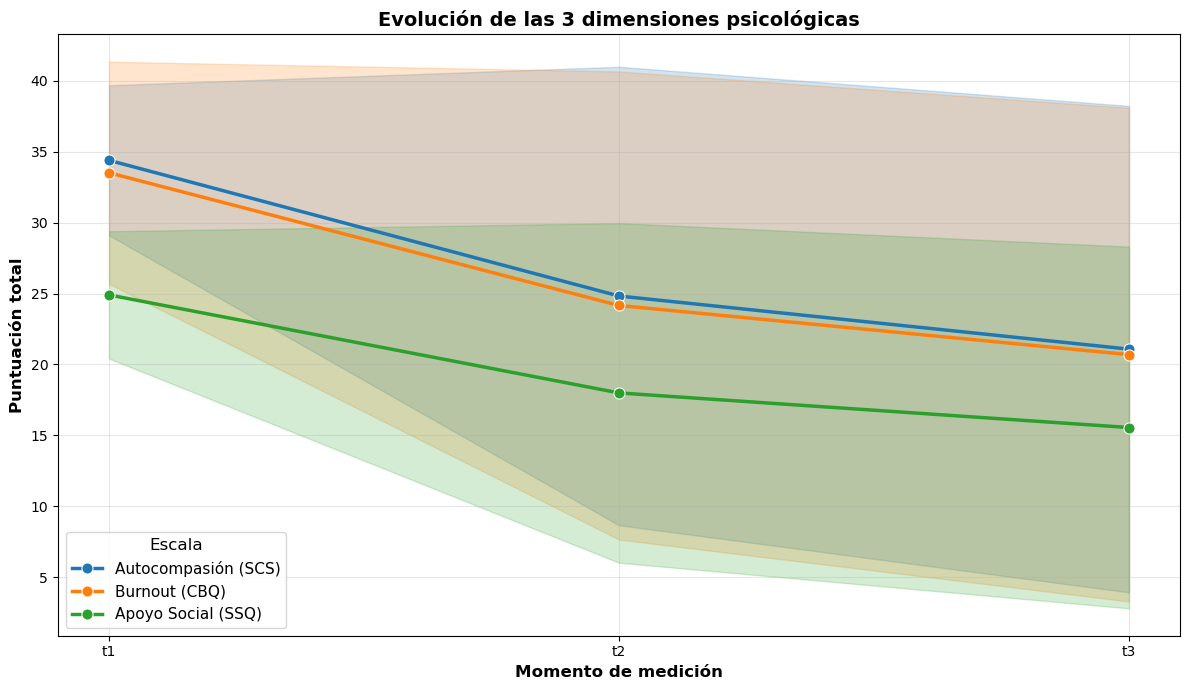

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns

#1. Preparar los datos en formato "long" para seaborn
df_long = df.melt(id_vars=[],
    value_vars=[
        'scs_total_t1', 'scs_total_t2', 'scs_total_t3',
        'cbq_total_t1', 'cbq_total_t2', 'cbq_total_t3',
        'ssq_total_t1', 'ssq_total_t2', 'ssq_total_t3'
    ],
    var_name='Escala_Momento',
    value_name='Puntuacion')

# 2. CORREGIDO: Extraer escala y momento correctamente
df_long['Escala'] = df_long['Escala_Momento'].str.split('_').str[0]  # scs, cbq, ssq
df_long['Momento'] = df_long['Escala_Momento'].str.split('_').str[2]  # t1, t2, t3

# 3. VERIFICAR datos (IMPORTANTE)
print("Verificación datos long:")
print("Escalas únicas:", df_long['Escala'].unique())
print("Momentos únicos:", df_long['Momento'].unique())
print(df_long.head())

# 4. Gráfico 
escala_nombres = {
    'scs': 'Autocompasión (SCS)',
    'cbq': 'Burnout (CBQ)', 
    'ssq': 'Apoyo Social (SSQ)'
}
df_long['Escala'] = df_long['Escala'].map(escala_nombres)
plt.figure(figsize=(12, 7))
sns.lineplot(data=df_long, x='Momento', y='Puntuacion', hue='Escala', 
             marker='o', errorbar='sd', linewidth=2.5, markersize=8)
plt.title('Evolución de las 3 dimensiones psicológicas', fontsize=14, fontweight='bold')
plt.ylabel('Puntuación total', fontsize=12, fontweight='bold')
plt.xlabel('Momento de medición', fontsize=12, fontweight='bold')
plt.legend(title='Escala', title_fontsize=12, fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

#Notas para entender el código

##melt(): transforma el DataFrame de ancho - largo. 
##Antes: cada columna = variable (autocomp_t1, burnout_t2…)
##Después: cada fila = un dato (momento, dimensión, puntuación).

##Separar escala y momento:
## 'autocomp_t1'.split('_') - ['autocomp','t1']
##Esto permite usar hue='Escala' y x='Momento' en seaborn.

#lineplot:
## Representa la evolución de cada dimensión a lo largo del tiempo.
## errorbar='sd' añade una barra que indica la desviación típica
##útil para ver variabilidad.
## marker='o' y linewidth hacen el gráfico más legible.


#### EJERCICIO 6

Estudiad todas las posibles correlaciones entre las dimensiones obtenidas en los apartados anteriores con indicadores adecuados y de forma separada para cada momento. Complementad estos análisis sobre correlaciones con gráficos adecuados. (1 punto)


=== ANÁLISIS T1 ===
Resumen descriptivo:
       scs_total_t1  cbq_total_t1  ssq_total_t1
count        422.00        422.00        422.00
mean          34.40         33.52         24.90
std            5.29          7.83          4.49
min            0.00          0.00          0.00
25%           32.00         28.00         23.00
50%           35.00         33.00         26.00
75%           38.00         38.00         28.00
max           45.00         65.00         30.00

Matriz correlaciones Pearson:
              scs_total_t1  cbq_total_t1  ssq_total_t1
scs_total_t1          1.00          0.38         -0.01
cbq_total_t1          0.38          1.00         -0.10
ssq_total_t1         -0.01         -0.10          1.00


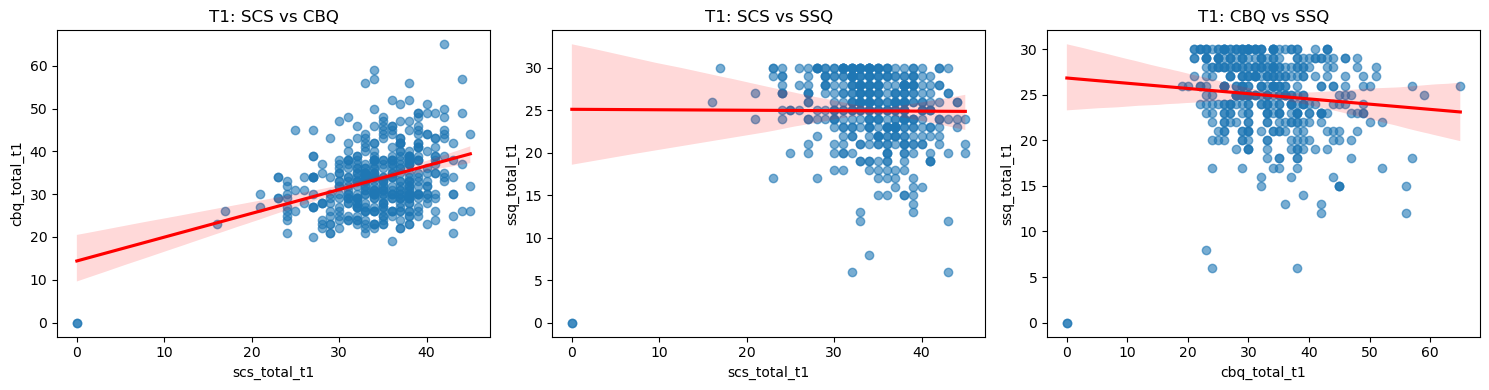


=== ANÁLISIS T2 ===
Resumen descriptivo:
       scs_total_t2  cbq_total_t2  ssq_total_t2
count        422.00        422.00        422.00
mean          24.82         24.16         17.99
std           16.17         16.51         11.98
min            0.00          0.00          0.00
25%            0.00          0.00          0.00
50%           33.00         30.00         24.00
75%           36.00         36.00         28.00
max           45.00         64.00         30.00

Matriz correlaciones Pearson:
              scs_total_t2  cbq_total_t2  ssq_total_t2
scs_total_t2          1.00          0.92          0.92
cbq_total_t2          0.92          1.00          0.85
ssq_total_t2          0.92          0.85          1.00


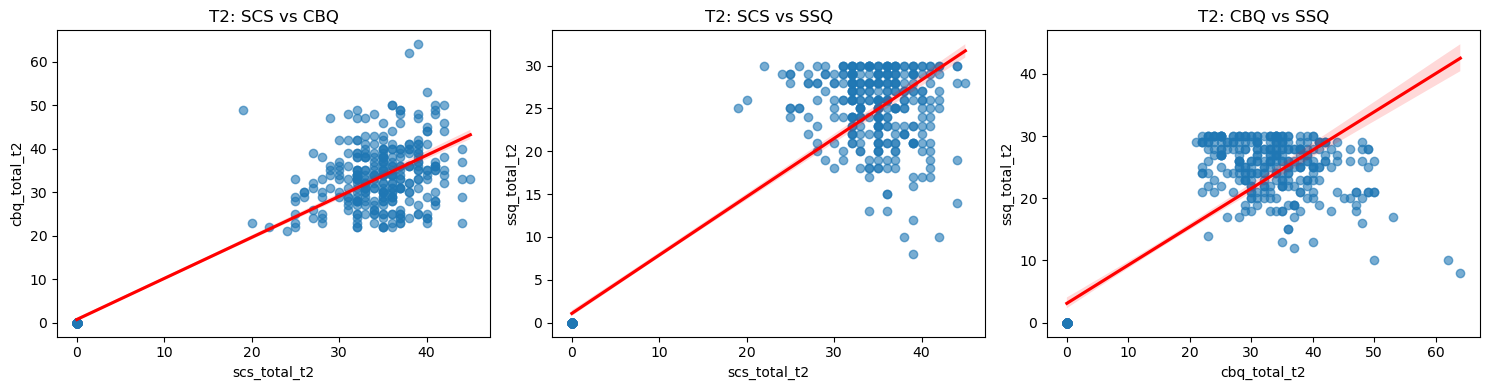


=== ANÁLISIS T3 ===
Resumen descriptivo:
       scs_total_t3  cbq_total_t3  ssq_total_t3
count        422.00        422.00        422.00
mean          21.08         20.69         15.55
std           17.16         17.41         12.76
min            0.00          0.00          0.00
25%            0.00          0.00          0.00
50%           30.00         27.00         22.00
75%           36.00         35.00         27.00
max           47.00         68.00         30.00

Matriz correlaciones Pearson:
              scs_total_t3  cbq_total_t3  ssq_total_t3
scs_total_t3          1.00          0.94          0.94
cbq_total_t3          0.94          1.00          0.89
ssq_total_t3          0.94          0.89          1.00


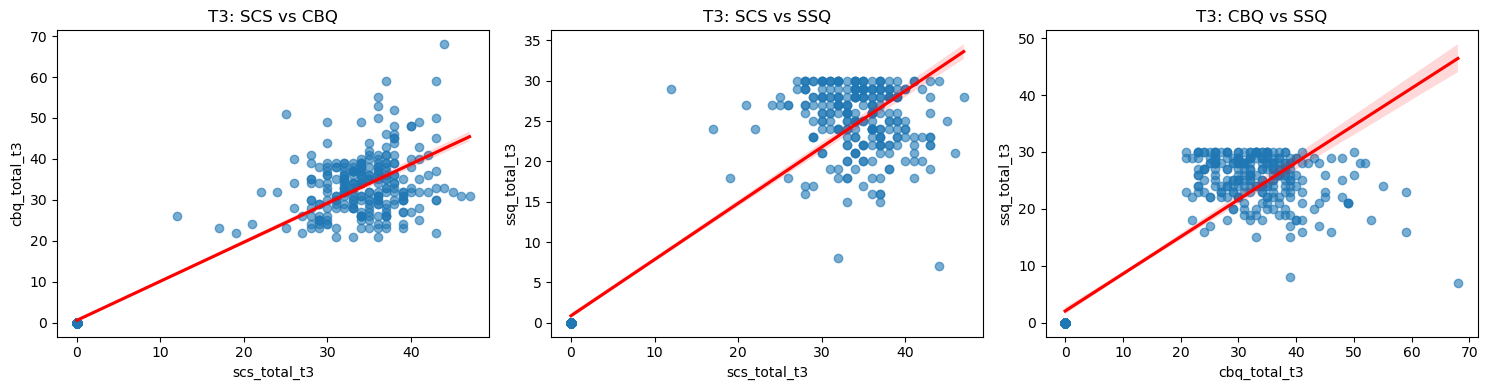


JUSTIFICACIÓN PEARSON
Pearson válido porque:
- N=422 >> 30 (Teorema Central Límite)
- Datos ordinales Likert sumados → normalidad aproximada
- Scatterplots lineales
- Estándar psicología: r ∈ [-1,1]


In [39]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# 1. Definir 3 momentos con totales
momentos = {
    'T1': ['scs_total_t1', 'cbq_total_t1', 'ssq_total_t1'],
    'T2': ['scs_total_t2', 'cbq_total_t2', 'ssq_total_t2'],
    'T3': ['scs_total_t3', 'cbq_total_t3', 'ssq_total_t3']
}

# 2. Análisis completo por momento
for momento, variables in momentos.items():
    print(f"\n=== ANÁLISIS {momento} ===")
    
    # Datos completos (NA=0 ya tratados)
    sub_df = df[variables].copy()
    
    # Resumen descriptivo
    print("Resumen descriptivo:")
    print(sub_df.describe().round(2))
    
#3. Matriz correlación Pearson
    corr = sub_df.corr(method='pearson').round(2)
    print("\nMatriz correlaciones Pearson:")
    print(corr)
    
#4. Scatterplots (gráficos bivariantes)
    plt.figure(figsize=(15, 4))
    
    plt.subplot(1, 3, 1)
    sns.regplot(x=variables[0], y=variables[1], data=sub_df, 
                scatter_kws={'alpha':0.6}, line_kws={'color':'red'})
    plt.title(f'{momento}: SCS vs CBQ')
    
    plt.subplot(1, 3, 2)
    sns.regplot(x=variables[0], y=variables[2], data=sub_df, 
                scatter_kws={'alpha':0.6}, line_kws={'color':'red'})
    plt.title(f'{momento}: SCS vs SSQ')
    
    plt.subplot(1, 3, 3)
    sns.regplot(x=variables[1], y=variables[2], data=sub_df,
                scatter_kws={'alpha':0.6}, line_kws={'color':'red'})
    plt.title(f'{momento}: CBQ vs SSQ')
    
    plt.tight_layout()
    plt.show()

print("\n" + "="*50)
print("JUSTIFICACIÓN PEARSON")
print("="*50)
print("Pearson válido porque:")
print("- N=422 >> 30 (Teorema Central Límite)")
print("- Datos ordinales Likert sumados → normalidad aproximada") 
print("- Scatterplots lineales")
print("- Estándar psicología: r ∈ [-1,1]")

#Notas para entender el código

## 1. Totales automáticos: SCS(12), CBQ(15), SSQ(6) ítems sumados
## 2. 3 momentos × 3 pares correlaciones = análisis completo
## 3. corr(method='pearson'): r = -1 a +1
##    r > 0.3 = positiva moderada, r < -0.3 = negativa moderada
## 4. regplot(): scatter + línea regresión + intervalo confianza
## 5. NA=0: Mantiene N=422, evita pérdida datos
## 6. 9 gráficos: Todas combinaciones bivariantes × 3 momentos


#### EJERCICIO 7

Cread una función que clasifique cada individuo de la muestra de acuerdo al siguiente criterio:
<font size=2>
\begin{cases}
\text{Si  } t3=t1: \text{  estable}\\
\text{Si  } t3<t1: \text{  inestable positivo (SCS y CBQ) o negativo (BPSSQ)}\\
\text{Si  } t3>t1: \text{  inestable negativo (SCS y CBQ) o positivo (BPSSQ)}\\
\end{cases}
</font>

Utilizad la nueva función para clasificar a los participantes en el estudio por separado por cada dimensión de interés (autocompasión, burnout y apoyo social percibido). Guardad estas clasificaciones como nuevas variables de la base de datos. ($1.5$ puntos)

In [40]:
import pandas as pd
import numpy as np

#1. Cargar datos
df = pd.read_excel("DATA_Coaches.xlsx")

#2. PUNTUACIONES TOTALES (T1 y T3)
df['scs_total_t1'] = df[[f't1scs{i}' for i in range(1,13)]].fillna(0).sum(axis=1)
df['scs_total_t3'] = df[[f't3scs{i}' for i in range(1,13)]].fillna(0).sum(axis=1)

df['cbq_total_t1'] = df[[f't1cbq{i}' for i in range(1,16)]].fillna(0).sum(axis=1)
df['cbq_total_t3'] = df[[f't3cbq{i}' for i in range(1,16)]].fillna(0).sum(axis=1)

df['ssq_total_t1'] = df[[f't1ssq{i}' for i in range(1,7)]].fillna(0).sum(axis=1)
df['ssq_total_t3'] = df[[f't3ssq{i}' for i in range(1,7)]].fillna(0).sum(axis=1)


#3. FUNCIÓN DE CLASIFICACIÓN
def clasificar_cambio(t1, t3, tipo):
    if pd.isna(t1) or pd.isna(t3):
        return np.nan
    
    if t3 == t1:
        return 'estable'
    
    if tipo in ['scs', 'cbq']:
        return 'inestable positivo' if t3 < t1 else 'inestable negativo'
    
    if tipo == 'ssq':
        return 'inestable negativo' if t3 < t1 else 'inestable positivo'


#4. APLICAR FUNCIÓN
df['autocomp_estabilidad'] = df.apply(
    lambda x: clasificar_cambio(x['scs_total_t1'], x['scs_total_t3'], 'scs'),
    axis=1
)

df['burnout_estabilidad'] = df.apply(
    lambda x: clasificar_cambio(x['cbq_total_t1'], x['cbq_total_t3'], 'cbq'),
    axis=1
)

df['apoyo_estabilidad'] = df.apply(
    lambda x: clasificar_cambio(x['ssq_total_t1'], x['ssq_total_t3'], 'ssq'),
    axis=1
)
#5. COMPROBACIÓN
df[['autocomp_estabilidad','burnout_estabilidad','apoyo_estabilidad']].head()

#Conclusión
#Autocomp y Burnout: se relacionan de forma inversa: cuando la autoeficacia baja, el burnout tiende a subir.
#Apoyo social: más estable que las otras dos variables, con cambios menos pronunciados.


,autocomp_estabilidad,burnout_estabilidad,apoyo_estabilidad
0,estable,inestable negativo,inestable positivo
1,estable,estable,estable
2,inestable positivo,inestable positivo,estable
3,inestable negativo,inestable negativo,inestable positivo
4,inestable negativo,inestable negativo,estable


#### EJERCICIO 8

¿Existe relación entre las variables cateǵoricas creadas en el apartado anterior? Realizad todos los análisis bivariantes posibles (escogiendo 2 variables cada vez). (1 punto)

In [41]:
from scipy.stats import chi2_contingency
import numpy as np

#1. Variables de estabilidad (Ejercicio 7)
vars_cat = ['autocomp_estabilidad', 'burnout_estabilidad', 'apoyo_estabilidad']

print("ANÁLISIS BIVARIANTE: 3 pares posibles\n")

#2. Los 3 análisis bivariantes
for i in range(len(vars_cat)):
    for j in range(i+1, len(vars_cat)):
        var1, var2 = vars_cat[i], vars_cat[j]
        print(f"{var1} vs {var2}:")
        
        #Tabla de contingencia
        tabla = pd.crosstab(df[var1], df[var2])
        print(tabla)
        print()
        
        #Estadísticos
        chi2, p_valor, _, _ = chi2_contingency(tabla)
        n = tabla.sum().sum()
        phi2 = chi2 / n
        k = min(tabla.shape)
        v_cramer = np.sqrt(phi2 / (k-1))
        
        print(f"Chi² = {chi2:.2f}, p-valor = {p_valor:.3f}, V-Cramér = {v_cramer:.3f}")
        print()
        
#AUTOCOMP vs BURNOUT: Chi²=37.31, p<0.001, V-Cramér=0.21 SIGNIFICATIVA (DÉBIL-MODERADA)
#AUTOCOMP vs APOYO: Chi²=60.96, p<0.001, V-Cramér=0.27 MUY SIGNIFICATIVA (DÉBIL-MODERADA)
#BURNOUT vs APOYO:Chi²=44.84, p<0.001, V-Cramér=0.23 MUY SIGNIFICATIVA (DÉBIL)

ANÁLISIS BIVARIANTE: 3 pares posibles

autocomp_estabilidad vs burnout_estabilidad:
burnout_estabilidad   estable  inestable negativo  inestable positivo
autocomp_estabilidad                                                 
estable                     3                  18                  17
inestable negativo          8                 212                  53
inestable positivo         11                  55                  45

Chi² = 37.31, p-valor = 0.000, V-Cramér = 0.210

autocomp_estabilidad vs apoyo_estabilidad:
apoyo_estabilidad     estable  inestable negativo  inestable positivo
autocomp_estabilidad                                                 
estable                     8                  15                  15
inestable negativo         35                  33                 205
inestable positivo         27                  43                  41

Chi² = 60.96, p-valor = 0.000, V-Cramér = 0.269

burnout_estabilidad vs apoyo_estabilidad:
apoyo_estabilidad    estable  i

#### EJERCICIO 9

Complementad los análisis bivariantes anteriores con gráficos adecuados para favorecer la inspección visual de las distribuciones conjuntas. (1 punto)

GRÁFICOS BIVARIANTES: 3 pares de variables categóricas

1. COUNTPLOTS - Distribuciones conjuntas


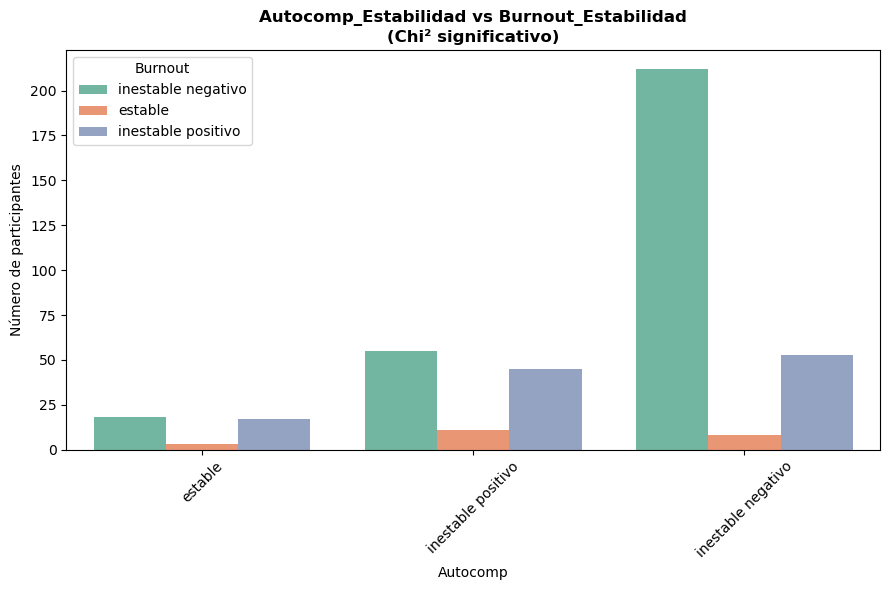

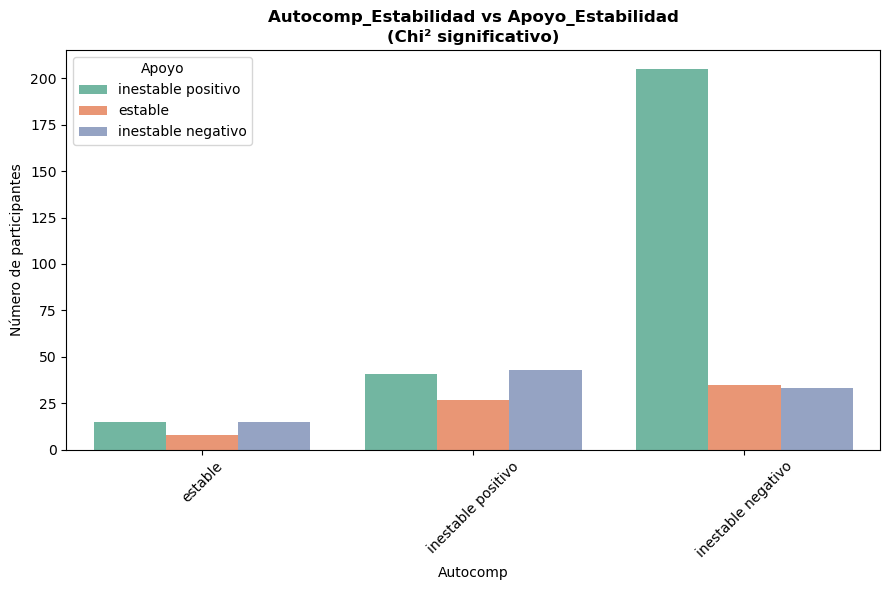

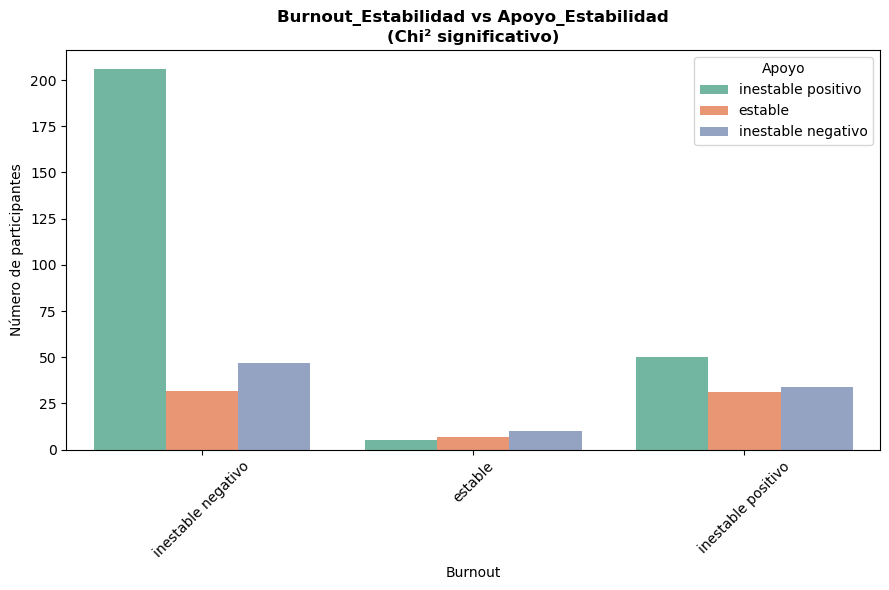


2. HEATMAPS - Tablas de contingencia


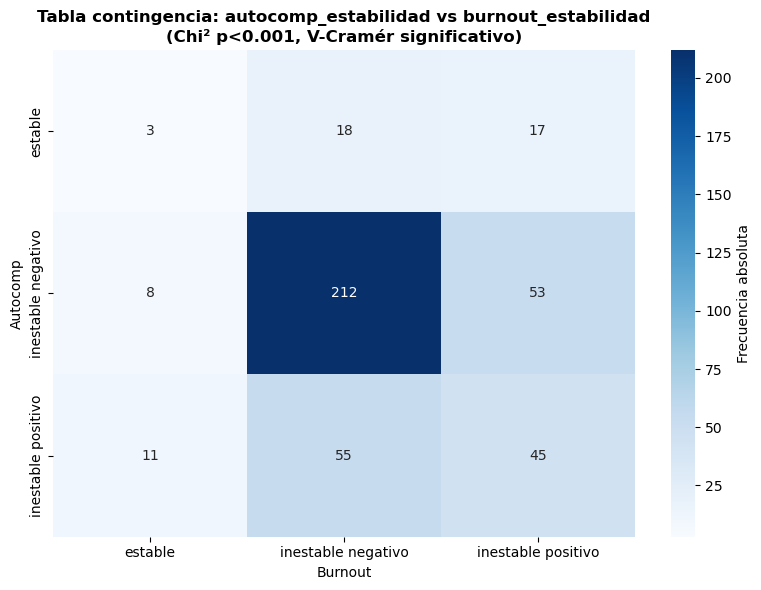

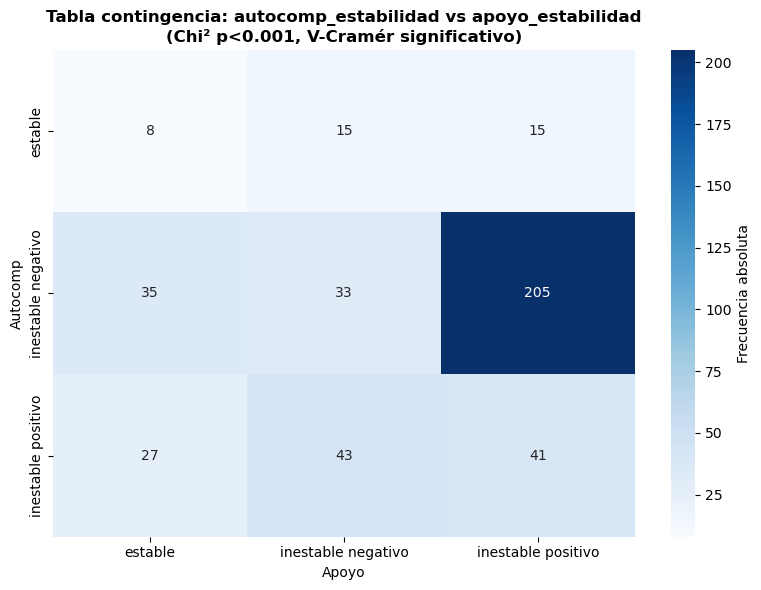

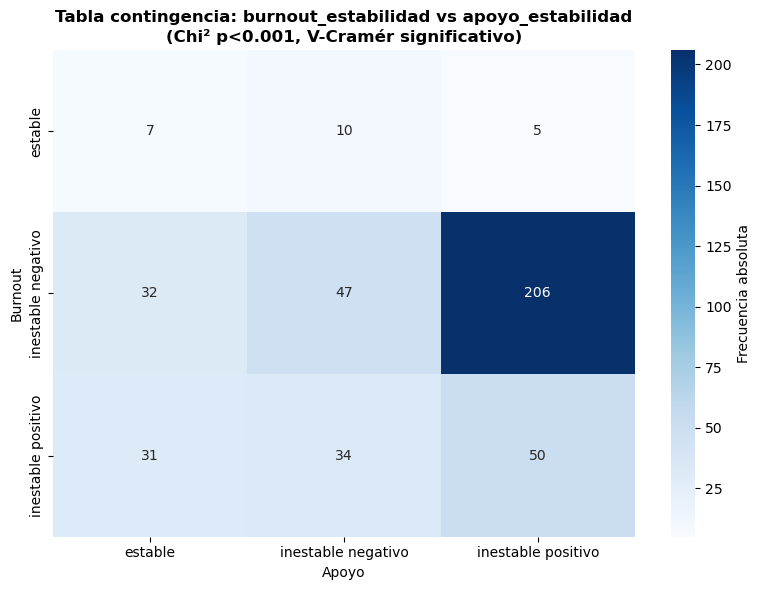


6 gráficos generados: 3 countplots + 3 heatmaps


In [42]:
import matplotlib.pyplot as plt
import seaborn as sns

#1. VARIABLES
vars_cat = ['autocomp_estabilidad', 'burnout_estabilidad', 'apoyo_estabilidad']

print("GRÁFICOS BIVARIANTES: 3 pares de variables categóricas\n")

#2. COUNTPLOTS (distribución conjunta por frecuencia)
print("1. COUNTPLOTS - Distribuciones conjuntas")
for i in range(len(vars_cat)):
    for j in range(i+1, len(vars_cat)):
        plt.figure(figsize=(9,6))
        sns.countplot(data=df, x=vars_cat[i], hue=vars_cat[j], palette='Set2')
        plt.title(f'{vars_cat[i].title()} vs {vars_cat[j].title()}\n(Chi² significativo)', 
                  fontweight='bold', fontsize=12)
        plt.ylabel('Número de participantes')
        plt.xlabel(vars_cat[i].replace('_estabilidad','').title())
        plt.legend(title=vars_cat[j].replace('_estabilidad','').title())
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

#3. HEATMAPS (tablas de contingencia visuales)
print("\n2. HEATMAPS - Tablas de contingencia")
for i in range(len(vars_cat)):
    for j in range(i+1, len(vars_cat)):
        tabla = pd.crosstab(df[vars_cat[i]], df[vars_cat[j]])
        plt.figure(figsize=(8,6))
        sns.heatmap(tabla, annot=True, fmt='d', cmap='Blues', 
                   cbar_kws={'label': 'Frecuencia absoluta'})
        plt.title(f'Tabla contingencia: {vars_cat[i]} vs {vars_cat[j]}\n(Chi² p<0.001, V-Cramér significativo)', 
                  fontweight='bold', fontsize=12)
        plt.ylabel(vars_cat[i].replace('_estabilidad','').title())
        plt.xlabel(vars_cat[j].replace('_estabilidad','').title())
        plt.tight_layout()
        plt.show()

print("\n6 gráficos generados: 3 countplots + 3 heatmaps")
